In [1]:
import os
import requests
import zipfile
from tqdm import tqdm
import argparse

def download_file(url, output_path):
    """
    Download file with progress bar
    """
    response = requests.get(url, stream=True)
    total_size = int(response.headers.get('content-length', 0))
    
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    
    with open(output_path, 'wb') as file, tqdm(
        desc=os.path.basename(output_path),
        total=total_size,
        unit='iB',
        unit_scale=True,
        unit_divisor=1024,
    ) as bar:
        for data in response.iter_content(chunk_size=1024):
            size = file.write(data)
            bar.update(size)

def download_ravdess(output_dir='data/full/RAVDESS'):
    """
    Download RAVDESS dataset
    """
    print("Downloading RAVDESS dataset...")
    url = "https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip"
    zip_path = f"{output_dir}.zip"
    
    # Download
    download_file(url, zip_path)
    
    # Extract
    print("Extracting files...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(output_dir)
    
    # Cleanup
    os.remove(zip_path)
    
    print(f"✓ RAVDESS downloaded to {output_dir}")
    
    # Count files
    import glob
    num_files = len(glob.glob(f"{output_dir}/Actor_*/*.wav"))
    print(f"  Total files: {num_files}")

def download_whisper_model(model_size='base'):
    """
    Download Whisper model for offline use
    """
    print(f"Downloading Whisper {model_size} model...")
    import whisper
    model = whisper.load_model(model_size)
    print(f"✓ Whisper {model_size} model downloaded")
    return model

def download_noise_samples(output_dir='data/noise'):
    """
    Download background noise samples
    (Placeholder - you need to get these from DEMAND, ESC-50, etc.)
    """
    print("Note: Download noise samples manually from:")
    print("  - DEMAND: https://www.kaggle.com/aanhari/demand-dataset")
    print("  - ESC-50: https://github.com/karolpiczak/ESC-50")
    print("  - UrbanSound8K: https://urbansounddataset.weebly.com/")
    
    os.makedirs(output_dir, exist_ok=True)
    print(f"  Place noise files in: {output_dir}")

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument('--output-dir', default='data/full', help='Output directory')
    parser.add_argument('--skip-ravdess', action='store_true', help='Skip RAVDESS download')
    parser.add_argument('--whisper-model', default='base', choices=['tiny', 'base', 'small'])
    args = parser.parse_args()
    
    # Download datasets
    if not args.skip_ravdess:
        download_ravdess(os.path.join(args.output_dir, 'RAVDESS'))
    
    # Download Whisper
    download_whisper_model(args.whisper_model)
    
    # Noise samples (manual)
    download_noise_samples(os.path.join(args.output_dir, 'noise'))
    
    print("\n✓ All downloads complete!")
    print(f"  Dataset location: {args.output_dir}")

if __name__ == '__main__':
    main()


### 2. Audio Preprocessing Script



"""
Preprocess audio files (normalization, trimming, resampling)
"""
import os
import librosa
import soundfile as sf
import numpy as np
from tqdm import tqdm
import glob
import argparse

def preprocess_audio_file(input_path, output_path, sr=16000):
    """
    Preprocess single audio file
    
    Steps:
    1. Load audio
    2. Resample to target sample rate
    3. Trim silence
    4. Normalize volume
    5. Save
    """
    try:
        # Load
        audio, orig_sr = librosa.load(input_path, sr=None)
        
        # Resample if needed
        if orig_sr != sr:
            audio = librosa.resample(audio, orig_sr=orig_sr, target_sr=sr)
        
        # Trim silence (top_db: threshold in dB)
        audio, _ = librosa.effects.trim(audio, top_db=20)
        
        # Normalize
        audio = librosa.util.normalize(audio)
        
        # Save
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        sf.write(output_path, audio, sr)
        
        return True
    except Exception as e:
        print(f"Error processing {input_path}: {e}")
        return False

def preprocess_dataset(input_dir, output_dir, sr=16000):
    """
    Preprocess entire dataset
    """
    # Find all WAV files
    audio_files = glob.glob(f"{input_dir}/**/*.wav", recursive=True)
    
    print(f"Found {len(audio_files)} audio files")
    print(f"Preprocessing to: {output_dir}")
    
    success_count = 0
    
    for input_path in tqdm(audio_files, desc="Preprocessing"):
        # Create output path (preserve directory structure)
        rel_path = os.path.relpath(input_path, input_dir)
        output_path = os.path.join(output_dir, rel_path)
        
        # Preprocess
        if preprocess_audio_file(input_path, output_path, sr):
            success_count += 1
    
    print(f"\n✓ Preprocessing complete!")
    print(f"  Success: {success_count}/{len(audio_files)} files")
    print(f"  Output: {output_dir}")

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument('--input', required=True, help='Input directory')
    parser.add_argument('--output', required=True, help='Output directory')
    parser.add_argument('--sample-rate', type=int, default=16000, help='Target sample rate')
    args = parser.parse_args()
    
    preprocess_dataset(args.input, args.output, args.sample_rate)

if __name__ == '__main__':
    main()

usage: ipykernel_launcher.py [-h] [--output-dir OUTPUT_DIR] [--skip-ravdess]
                             [--whisper-model {tiny,base,small}]
ipykernel_launcher.py: error: unrecognized arguments: --f=c:\Users\adhit\AppData\Roaming\jupyter\runtime\kernel-v3b64406a3dafff61f9bb1775920bb818b13e58440.json


SystemExit: 2

C:\Users\adhit\AppData\Roaming\Python\Python312\site-packages\IPython\core\interactiveshell.py:3675: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


Found 2939 audio files and 2939 transcripts.


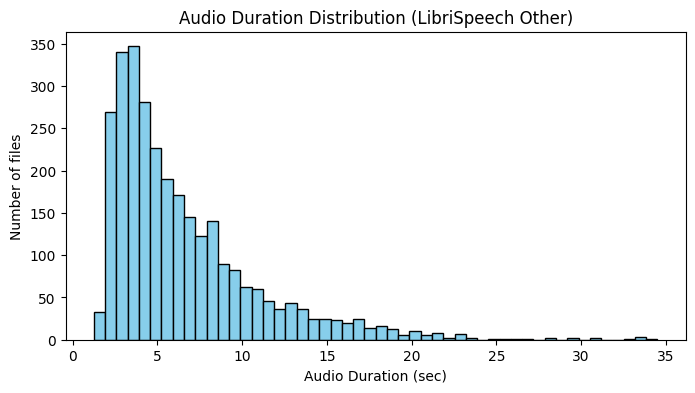

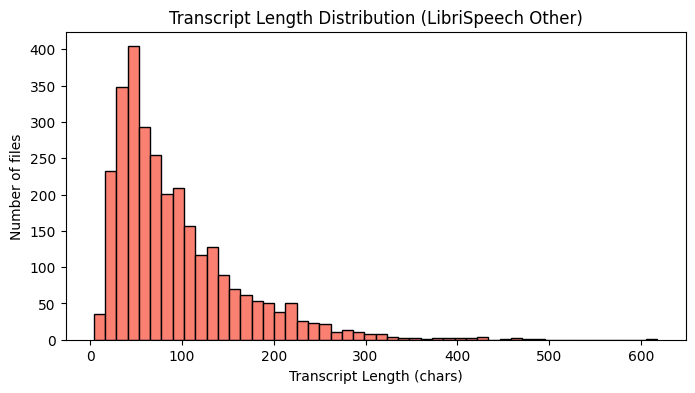

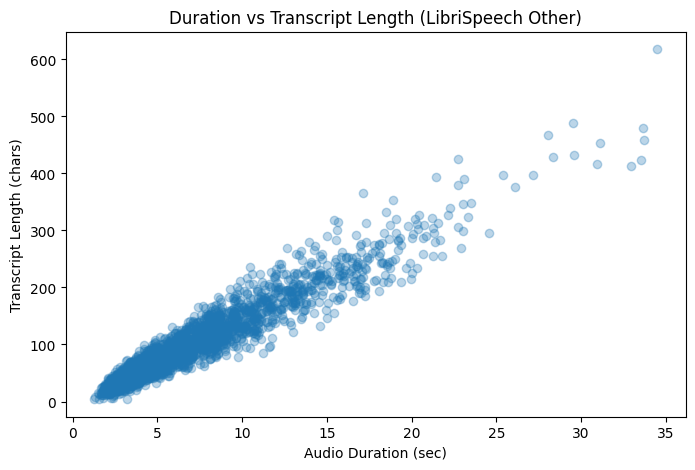

TypeError: melspectrogram() takes 0 positional arguments but 1 positional argument (and 1 keyword-only argument) were given

In [9]:
import os
import random
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# 1. Set your LibriSpeech "other" folder
# -----------------------------
dataset_folder = r"C:\Users\adhit\Downloads\test-other\LibriSpeech\test-other"  # <-- your path

# -----------------------------
# 2. Collect all audio (FLAC) and transcript files
# -----------------------------
audio_files = []
transcript_dict = {}

for root, _, files in os.walk(dataset_folder):
    for file in files:
        if file.endswith(".flac"):
            audio_files.append(os.path.join(root, file))
        elif file.endswith(".txt"):
            txt_path = os.path.join(root, file)
            with open(txt_path, "r") as f:
                for line in f:
                    parts = line.strip().split(" ", 1)
                    if len(parts) == 2:
                        transcript_dict[parts[0]] = parts[1]

print(f"Found {len(audio_files)} audio files and {len(transcript_dict)} transcripts.")

# -----------------------------
# 3. Calculate audio durations & transcript lengths
# -----------------------------
durations = []
transcript_lengths = []

for audio_path in audio_files:
    file_id = os.path.splitext(os.path.basename(audio_path))[0]
    # Load FLAC file
    y, sr = librosa.load(audio_path, sr=16000)
    durations.append(len(y)/sr)

    transcript = transcript_dict.get(file_id, "")
    transcript_lengths.append(len(transcript))

durations = np.array(durations)
transcript_lengths = np.array(transcript_lengths)

# -----------------------------
# 4. Plot Audio Duration Distribution
# -----------------------------
plt.figure(figsize=(8,4))
plt.hist(durations, bins=50, color='skyblue', edgecolor='black')
plt.xlabel("Audio Duration (sec)")
plt.ylabel("Number of files")
plt.title("Audio Duration Distribution (LibriSpeech Other)")
plt.show()

# -----------------------------
# 5. Plot Transcript Length Distribution
# -----------------------------
plt.figure(figsize=(8,4))
plt.hist(transcript_lengths, bins=50, color='salmon', edgecolor='black')
plt.xlabel("Transcript Length (chars)")
plt.ylabel("Number of files")
plt.title("Transcript Length Distribution (LibriSpeech Other)")
plt.show()

# -----------------------------
# 6. Plot Duration vs Transcript Length
# -----------------------------
plt.figure(figsize=(8,5))
plt.scatter(durations, transcript_lengths, alpha=0.3)
plt.xlabel("Audio Duration (sec)")
plt.ylabel("Transcript Length (chars)")
plt.title("Duration vs Transcript Length (LibriSpeech Other)")
plt.show()

# -----------------------------
# 7. Plot Mel Spectrogram of Random Samples
# -----------------------------
num_samples = 3
sample_files = random.sample(audio_files, num_samples)

for audio_path in sample_files:
    y, sr = librosa.load(audio_path, sr=16000)
    S = librosa.feature.melspectrogram(y, sr=sr, n_mels=128)
    S_db = librosa.power_to_db(S, ref=np.max)

    plt.figure(figsize=(10,4))
    librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"Mel Spectrogram: {os.path.basename(audio_path)}")
    plt.tight_layout()
    plt.show()